In [2]:
import polars as pl
import json
from typing import List, Dict

In [5]:
interactions_output_parquet_path = '/home/jovyan/IRec/sigir/Beauty_new/inter_new.parquet'
# 1. Загружаем
df = pl.read_parquet(interactions_output_parquet_path)

In [6]:
def split_session_by_timestamps(
    df: pl.DataFrame,
    time_cutoffs: List[int],
    output_dir: str = None,
    return_dicts: bool = True
) -> List[Dict[int, List[int]]]:
    """
    Разбивает датасет по временным интервалам и возвращает JSON-подобные словари.
    
    Args:
        df: Polars DataFrame с колонками uid, item_ids (list), timestamps (list)
        time_cutoffs: Лист временных точек для разбиения
        output_dir: Директория для сохранения JSON файлов (опционально)
        return_dicts: Возвращать ли словари (как json_data format)
    
    Returns:
        Лист словарей в формате {user_id: [item_ids для интервала]}
    
    Example:
        >>> df = pl.read_parquet("inter_new.parquet")
        >>> cutoffs = [1000000, 2000000, 3000000]
        >>> dicts = split_session_by_timestamps(df, cutoffs, output_dir="./data")
        >>> # Получим 4 JSON файла за каждый интервал + последний
    """
    
    result_dicts = []
    
    def extract_interval(df_source, start, end=None):
        """Извлекает данные для одного временного интервала"""
        q = df_source.lazy()
        q = q.explode(["item_ids", "timestamps"])
        
        if end is not None:
            q = q.filter(
                (pl.col("timestamps") >= start) & 
                (pl.col("timestamps") < end)
            )
        else:
            q = q.filter(
                pl.col("timestamps") >= start
            )
            
        q = q.group_by("uid").agg([
            pl.col("item_ids").alias("item_ids")
        ]).sort("uid")
        
        return q.collect()
    
    # Генерируем интервалы
    intervals = []
    current_start = 0
    for cutoff in time_cutoffs:
        intervals.append((current_start, cutoff))
        current_start = cutoff
    # Последний интервал от последнего cutoff до бесконечности
    intervals.append((current_start, None))
    
    # Обрабатываем каждый интервал
    for start, end in intervals:
        subset = extract_interval(df, start, end)
        
        # Конвертируем в JSON-подобный словарь
        json_dict = {}
        for user_id, item_ids in subset.iter_rows():
            json_dict[user_id] = item_ids
        
        result_dicts.append(json_dict)
        
        # Опционально сохраняем файлы
        if output_dir:
            if end is not None:
                filename = f"inter_new_[{start}_{end}).json"
            else:
                filename = f"inter_new_[{start}_inf).json"
            
            filepath = f"{output_dir}/{filename}"
            with open(filepath, 'w') as f:
                json.dump(json_dict, f, indent=2)
            
            print(f"✓ Сохранено: {filepath}")
    
    return result_dicts

In [7]:
global_max_time = df.select(
    pl.col("timestamps").explode().max()
).item()

# 3. Размер окна (неделя)
days_val = 14
window_sec = days_val * 24 * 3600 

# 4. Три отсечки с конца
cutoff_test_start = global_max_time - window_sec      # T - 2w
cutoff_val_start  = global_max_time - 2 * window_sec  # T - 4w
cutoff_gap_start  = global_max_time - 3 * window_sec  # T - 6w

cutoffs = [
    int(cutoff_gap_start),  # Граница Part 0 | Part 1
    int(cutoff_val_start),  # Граница Part 1 | Part 2
    int(cutoff_test_start)  # Граница Part 2 | Part 3
]

print(f"Cutoffs: {cutoffs}")

# 5. Разбиваем на 4 файла
# Part 0: Deep History
# Part 1: Pre-Validation (нужна для s1, но выкидывается для 'совсем короткого' s0?)
#         *В вашем случае 4.2 просто 'на неделю короче', так что Part 1 все равно войдет в трейн Semantics, 
#         а выкинется только Part 2. Но если захотите еще короче - можно выкинуть и Part 1.*
# Part 2: Validation (Есть в 4.1, НЕТ в 4.2 для Semantics)
# Part 3: Test

split_files = split_session_by_timestamps(
    df, 
    cutoffs, 
    output_dir="/home/jovyan/IRec/sigir/Beauty_new/splits/test_splits"
)

names = ["Base", "Week -6", "Week -4", "Week -2"]
for i, d in enumerate(split_files):
    print(f"Part {i} [{names[i]}]: {len(d)} users")

Cutoffs: [1402444800, 1403654400, 1404864000]
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/splits/test_splits/inter_new_[0_1402444800).json
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/splits/test_splits/inter_new_[1402444800_1403654400).json
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/splits/test_splits/inter_new_[1403654400_1404864000).json
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/splits/test_splits/inter_new_[1404864000_inf).json
Part 0 [Base]: 22029 users
Part 1 [Week -6]: 1854 users
Part 2 [Week -4]: 1945 users
Part 3 [Week -2]: 1381 users


In [21]:
def merge_and_save(parts_to_merge, dirr, output_name):
    merged = {}
    print(f"Merging {len(parts_to_merge)} files into {output_name}...")
    
    for part in parts_to_merge:
        # with open(fp, 'r') as f:
        #     part = json.load(f)
        for uid, items in part.items():
            if uid not in merged:
                merged[uid] = []
            merged[uid].extend(items)
            
    out_path = f"{dirr}/{output_name}"
    with open(out_path, 'w') as f:
        json.dump(merged, f)
    print(f"✓ Done: {out_path} (Users: {len(merged)})")


# p0, p1, p2, p3 = split_files[0], split_files[1], split_files[2], split_files[3]

In [24]:
EXP_DIR = "../sigir/Beauty_new/splits/exp_data"

# Tiger: P0+P1
merge_and_save([p0, p1], EXP_DIR, "exp_4_inter_tiger_train.json")

# 1. Exp 4.1 (Standard)
# Semantics: P0+P1 (Всё кроме пропуска и теста)
merge_and_save([p0, p1], EXP_DIR, "exp_4.1_inter_semantics_train.json")

# 2. Exp 4.2 (Short Semantics)
# Semantics: P0 (Короче на неделю, без P2)
merge_and_save([p0], EXP_DIR, "exp_4.2_inter_semantics_train_short.json")

# 3. Exp 4.3 (Leak)
# Semantics: P0+P1+P2 (Видит валидацию)
merge_and_save([p0, p1, p2], EXP_DIR, "exp_4.3_inter_semantics_train_leak.json")

# 4. Test Set (тест всех моделей)
merge_and_save([p3], EXP_DIR, "test_set.json")

# 4. Valid Set (пропуск, имитируется разница трейна и теста чтобы потом дообучать)
merge_and_save([p2], EXP_DIR, "valid_skip_set.json")

print("\nAll done!")

Merging 2 files into exp_4_inter_tiger_train.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/exp_4_inter_tiger_train.json (Users: 22129)
Merging 2 files into exp_4.1_inter_semantics_train.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/exp_4.1_inter_semantics_train.json (Users: 22129)
Merging 1 files into exp_4.2_inter_semantics_train_short.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/exp_4.2_inter_semantics_train_short.json (Users: 22029)
Merging 3 files into exp_4.3_inter_semantics_train_leak.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/exp_4.3_inter_semantics_train_leak.json (Users: 22265)
Merging 1 files into test_set.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/test_set.json (Users: 1381)
Merging 1 files into valid_skip_set.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/valid_skip_set.json (Users: 1945)

All done!


In [25]:
merge_and_save([p0, p1, p2, p3], EXP_DIR, "all_set.json")

Merging 4 files into all_set.json...
✓ Done: ../sigir/Beauty_new/splits/exp_data/all_set.json (Users: 22363)


In [ ]:
with open("../data/Beauty/inter_new.json", 'r') as f:
    old_inter_new = json.load(f)

with open("../sigir/Beauty_new/splits/exp_data/exp_4.1_inter_semantics_train.json", 'r') as ff:
    first_sem = json.load(ff)
    
with open("../sigir/Beauty_new/splits/exp_data/exp_4.2_inter_semantics_train_short.json", 'r') as ff:
    second_sem = json.load(ff)
    
with open("../sigir/Beauty_new/splits/exp_data/exp_4.3_inter_semantics_train_leak.json", 'r') as ff:
    third_sem = json.load(ff)
    
with open("../sigir/Beauty_new/splits/exp_data/exp_4_inter_tiger_train.json", 'r') as ff:
    tiger_sem = json.load(ff)

with open("../sigir/Beauty_new/splits/exp_data/test_set.json", 'r') as ff:
    test_sem = json.load(ff)

def check_prefix_match(full_data, subset_data, check_suffix=False):
    """
    check_suffix=True включит режим проверки суффиксов (для теста).
    """
    mismatch_count = 0
    full_match_count = 0
    
    # Итерируемся по ключам сабсета, так как в full_data может быть больше юзеров
    for user, sub_items in subset_data.items():
        
        # Проверяем есть ли такой юзер в исходнике
        if user not in full_data:
            print(f"⚠ Юзер {user} не найден в исходном файле!")
            mismatch_count += 1
            continue
            
        full_items = full_data[user]
        
        # Логика для проверки ПРЕФИКСА (начало совпадает)
        if not check_suffix:
            if len(sub_items) > len(full_items):
                mismatch_count += 1
                continue
                
            # Сравниваем начало full с sub
            if full_items[:len(sub_items)] == sub_items:
                if len(full_items) == len(sub_items):
                    full_match_count += 1
            else:
                mismatch_count += 1
                
        # Логика для проверки СУФФИКСА (конец совпадает - для теста)
        else:
            if len(sub_items) > len(full_items):
                mismatch_count += 1
                continue
                
            # Сравниваем конец full с sub
            # Срез [-len:] берет последние N элементов
            if full_items[-len(sub_items):] == sub_items:
                 if len(full_items) == len(sub_items):
                    full_match_count += 1
            else:
                mismatch_count += 1

    mode = "СУФФИКСЫ" if check_suffix else "ПРЕФИКСЫ"
    
    if mismatch_count == 0:
        print(f"✅ [{mode}] Все {len(subset_data)} массивов ОК. Полных совпадений: {full_match_count}")
    else:
        print(f"❌ [{mode}] Найдено {mismatch_count} ошибок.")

# --- Запуск проверок ---
print("Проверка Train сетов (должны быть префиксами):")
check_prefix_match(old_inter_new, first_sem)
check_prefix_match(old_inter_new, second_sem)
check_prefix_match(old_inter_new, third_sem)
check_prefix_match(old_inter_new, tiger_sem)

print("\nПроверка Test сета (должен быть суффиксом):")
check_prefix_match(old_inter_new, test_sem, check_suffix=True)

print("\n(Контроль) Проверка Test сета как префикса (должна упасть):")
check_prefix_match(old_inter_new, test_sem, check_suffix=False)


Проверка Train сетов (должны быть префиксами):
✅ [ПРЕФИКСЫ] Все 22129 массивов ОК. Полных совпадений: 19410
✅ [ПРЕФИКСЫ] Все 22029 массивов ОК. Полных совпадений: 18191
✅ [ПРЕФИКСЫ] Все 22265 массивов ОК. Полных совпадений: 20982
✅ [ПРЕФИКСЫ] Все 22129 массивов ОК. Полных совпадений: 19410

Проверка Test сета (должен быть суффиксом):
✅ [СУФФИКСЫ] Все 1381 массивов ОК. Полных совпадений: 98

(Контроль) Проверка Test сета как префикса (должна упасть):
❌ [ПРЕФИКСЫ] Найдено 1283 ошибок.


In [1]:
суа

NameError: name 'суа' is not defined

--- Статистика по временным интервалам (Fixed Time Window) ---
Part 0 [Base]: 186516 events (Start -> 2014-06-11)
Part 1 [Gap (Week -6)]: 4073 events (2014-06-11 -> 2014-06-25)
Part 2 [Pre-Valid (Week -4)]: 4730 events (2014-06-25 -> 2014-07-09)
Part 3 [Test (Week -2)]: 3183 events (2014-07-09 -> Inf)


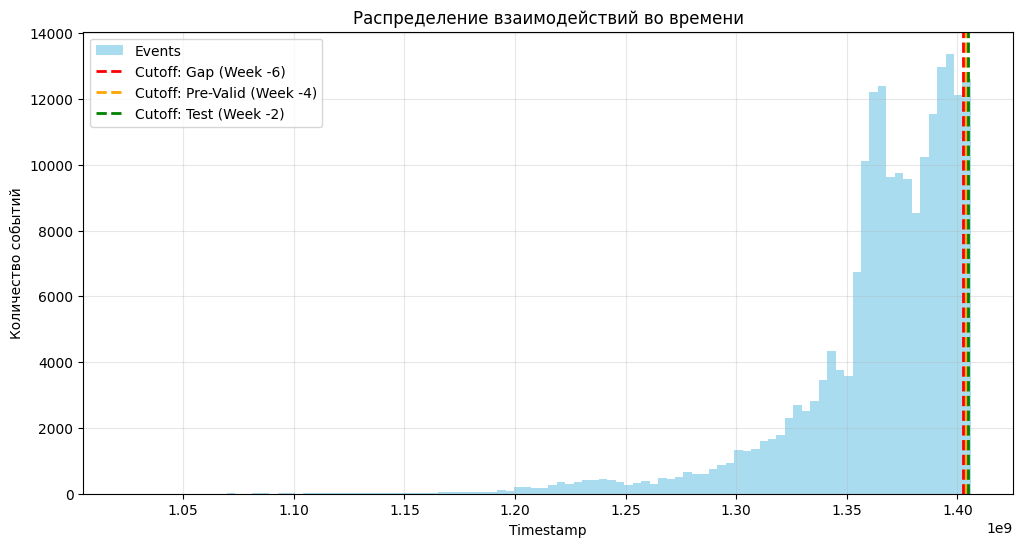

In [12]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime


# 2. Статистика по текущему временному разбиению
global_max_time = df.select(pl.col("timestamps").explode().max()).item()
days_val = 14
window_sec = days_val * 24 * 3600 

cutoffs = [
    int(global_max_time - 3 * window_sec),
    int(global_max_time - 2 * window_sec),
    int(global_max_time - 1 * window_sec)
]

print("--- Статистика по временным интервалам (Fixed Time Window) ---")
intervals = [0] + cutoffs + [None]
labels = ["Base", "Gap (Week -6)", "Pre-Valid (Week -4)", "Test (Week -2)"]

# Считаем события в каждом интервале
counts = []
for i in range(len(intervals)-1):
    start, end = intervals[i], intervals[i+1]
    
    q = df.lazy().explode(["timestamps"])
    if end is not None:
        q = q.filter((pl.col("timestamps") >= start) & (pl.col("timestamps") < end))
    else:
        q = q.filter(pl.col("timestamps") >= start)
        
    count = q.select(pl.len()).collect().item()
    counts.append(count)
    
    end_str = datetime.fromtimestamp(end).strftime('%Y-%m-%d') if end else "Inf"
    start_str = datetime.fromtimestamp(start).strftime('%Y-%m-%d') if start > 0 else "Start"
    
    print(f"Part {i} [{labels[i]}]: {count} events ({start_str} -> {end_str})")

# 3. Гистограмма распределения событий во времени
all_timestamps = df.select(pl.col("timestamps").explode()).to_series().to_numpy()

plt.figure(figsize=(12, 6))
plt.hist(all_timestamps, bins=100, color='skyblue', alpha=0.7, label='Events')

# Рисуем линии отсечек
colors = ['red', 'orange', 'green']
for cutoff, color, label in zip(cutoffs, colors, labels[1:]):
    plt.axvline(x=cutoff, color=color, linestyle='--', linewidth=2, label=f'Cutoff: {label}')

plt.title("Распределение взаимодействий во времени")
plt.xlabel("Timestamp")
plt.ylabel("Количество событий")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# QUANTILE CUTOFF

In [13]:
def get_quantile_cutoffs(df, num_parts=4, base_ratio=None):
    """
    Считает cutoffs так, чтобы разбить данные на части.
    
    Args:
        num_parts: На сколько частей делить "хвост" истории.
        base_ratio: Какую долю данных отдать в Base (самую первую часть). 
                    Если None, делит всё поровну.
    """
    # Достаем все таймстемпы в один плоский массив
    # Это может занять память, если данных очень много (>100M), но для Beauty (2M) это ок
    all_ts = df.select(pl.col("timestamps").explode()).to_series().sort()
    total_events = len(all_ts)
    
    print(f"Всего событий: {total_events}")
    
    cutoffs = []
    
    if base_ratio:
        # Сценарий: Base занимает X% (например 80%), а остаток делим поровну на 3 части (Valid, Gap, Test)
        # Остаток = 1 - base_ratio
        # Каждая малая часть = (1 - base_ratio) / num_parts_tail
        
        base_idx = int(total_events * base_ratio)
        cutoffs.append(all_ts[base_idx]) # Первый cutoff отделяет Base
        
        remaining_events = total_events - base_idx
        part_size = remaining_events // num_parts # Делим остаток на 3 части (P1, P2, P3)
        
        current_idx = base_idx
        for _ in range(num_parts-1): # Нам нужно еще 2 границы, чтобы получить 3 части
            current_idx += part_size
            cutoffs.append(all_ts[current_idx])
            
    else:
        # Сценарий: Просто делим всё на N равных частей
        step = total_events // num_parts
        for i in range(1, num_parts):
            idx = i * step
            cutoffs.append(all_ts[idx])
            
    return cutoffs


In [17]:
equal_event_cutoffs = get_quantile_cutoffs(df, num_parts=4, base_ratio=0.8)

print("\n--- Новые Cutoffs (по количеству событий) ---")
print(f"Cutoffs: {equal_event_cutoffs}")

# Проверка распределения
intervals_eq = [0] + equal_event_cutoffs + [None]
print(intervals_eq)
print("Проверка количества событий в новых частях:")
for i in range(len(intervals_eq)-1):
    start, end = intervals_eq[i], intervals_eq[i+1]
    q = df.lazy().explode(["timestamps"])
    if end:
        q = q.filter((pl.col("timestamps") >= start) & (pl.col("timestamps") < end))
    else:
        q = q.filter(pl.col("timestamps") >= start)
    count = q.select(pl.len()).collect().item()
    print(f"Part {i}: {count} events")

Всего событий: 198502

--- Новые Cutoffs (по количеству событий) ---
Cutoffs: [1394150400, 1397001600, 1399939200, 1403049600]
[0, 1394150400, 1397001600, 1399939200, 1403049600, None]
Проверка количества событий в новых частях:
Part 0: 158689 events
Part 1: 9965 events
Part 2: 9701 events
Part 3: 10137 events
Part 4: 10010 events


In [18]:
new_split_files = split_session_by_timestamps(
    df, 
    [1394150400, 1399939200, 1403049600], 
    output_dir="/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/raw"
)

names = ["Base", "Gap", "Valid", "Test"]
for i, d in enumerate(new_split_files):
    num_users = len(d)
    
    num_events = sum(len(items) for items in d.values())
    
    print(f"{i:<10} {names[i]:<10} {num_users:<10} {num_events:<10}")

✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/raw/inter_new_[0_1394150400).json
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/raw/inter_new_[1394150400_1399939200).json
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/raw/inter_new_[1399939200_1403049600).json
✓ Сохранено: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/raw/inter_new_[1403049600_inf).json
0          Base       20825      158689    
1          Gap        6816       19666     
2          Valid      3817       10137     
3          Test       3626       10010     


In [22]:
EXP_DIR = "/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps"

base_p, gap_p, valid_p, test_p = new_split_files[0], new_split_files[1], new_split_files[2], new_split_files[3]

# Tiger: base + gap
merge_and_save([base_p, gap_p], EXP_DIR, "exp_4_0.9_inter_tiger_train.json")

# 1. Exp 4.1 (Standard)
# Semantics: base + gap (Всё кроме валидации и теста)
merge_and_save([base_p, gap_p], EXP_DIR, "exp_4-1_0.9_inter_semantics_train.json")

# 2. Exp 4.2 (Short Semantics)
# Semantics: base (Короче на пропуск, без gap)
merge_and_save([base_p], EXP_DIR, "exp_4-2_0.8_inter_semantics_train.json")

# 3. Exp 4.3 (Leak)
# Semantics: base + gap + valid (Видит валидацию)
merge_and_save([base_p, gap_p, valid_p], EXP_DIR, "exp_4-3_0.95_inter_semantics_train.json")

# 4. Test Set (тест всех моделей)
merge_and_save([test_p], EXP_DIR, "test_set.json")

# 4. Valid Set (валидационный набор)
merge_and_save([valid_p], EXP_DIR, "valid_set.json")

# 4. All Set (все данные)
merge_and_save([base_p, gap_p, valid_p, test_p], EXP_DIR, "all_set.json")

print("All done!")

Merging 2 files into exp_4_0.9_inter_tiger_train.json...
✓ Done: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4_0.9_inter_tiger_train.json (Users: 21760)
Merging 2 files into exp_4-1_0.9_inter_semantics_train.json...
✓ Done: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4-1_0.9_inter_semantics_train.json (Users: 21760)
Merging 1 files into exp_4-2_0.8_inter_semantics_train.json...
✓ Done: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4-2_0.8_inter_semantics_train.json (Users: 20825)
Merging 3 files into exp_4-3_0.95_inter_semantics_train.json...
✓ Done: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4-3_0.95_inter_semantics_train.json (Users: 22079)
Merging 1 files into test_set.json...
✓ Done: /home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/test_set.json (Users: 3626)
Merging 1 files into valid_set.json...
✓ Done: /home/jovyan/I

In [24]:
with open("/home/jovyan/IRec/data/Beauty/inter_new.json", 'r') as f:
    old_inter_new = json.load(f)

with open("/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4-1_0.9_inter_semantics_train.json", 'r') as ff:
    first_sem = json.load(ff)
    
with open("/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4-2_0.8_inter_semantics_train.json", 'r') as ff:
    second_sem = json.load(ff)
    
with open("/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4-3_0.95_inter_semantics_train.json", 'r') as ff:
    third_sem = json.load(ff)
    
with open("/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/exp_4_0.9_inter_tiger_train.json", 'r') as ff:
    tiger_sem = json.load(ff)

with open("//home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/test_set.json", 'r') as ff:
    test_sem = json.load(ff)

with open("/home/jovyan/IRec/sigir/Beauty_new/updated_quantile_splits/merged_for_exps/all_set.json", 'r') as ff:
    all_test_data = json.load(ff)

def check_prefix_match(full_data, subset_data, check_suffix=False):
    """
    check_suffix=True включит режим проверки суффиксов (для теста).
    """
    mismatch_count = 0
    full_match_count = 0

    num_events_full_data = sum(len(items) for items in full_data.values())
    num_events_subset_data = sum(len(items) for items in subset_data.values())
    print(f"доля событий всего {(num_events_subset_data/num_events_full_data):.2f}:")
    
    # Итерируемся по ключам сабсета, так как в full_data может быть больше юзеров
    for user, sub_items in subset_data.items():
        
        # Проверяем есть ли такой юзер в исходнике
        if user not in full_data:
            print(f"⚠ Юзер {user} не найден в исходном файле!")
            mismatch_count += 1
            continue
            
        full_items = full_data[user]
        
        # Логика для проверки ПРЕФИКСА (начало совпадает)
        if not check_suffix:
            if len(sub_items) > len(full_items):
                mismatch_count += 1
                continue
                
            # Сравниваем начало full с sub
            if full_items[:len(sub_items)] == sub_items:
                if len(full_items) == len(sub_items):
                    full_match_count += 1
            else:
                mismatch_count += 1
                
        # Логика для проверки СУФФИКСА (конец совпадает - для теста)
        else:
            if len(sub_items) > len(full_items):
                mismatch_count += 1
                continue
                
            # Сравниваем конец full с sub
            # Срез [-len:] берет последние N элементов
            if full_items[-len(sub_items):] == sub_items:
                 if len(full_items) == len(sub_items):
                    full_match_count += 1
            else:
                mismatch_count += 1

    mode = "СУФФИКСЫ" if check_suffix else "ПРЕФИКСЫ"
    
    if mismatch_count == 0:
        print(f"✅ [{mode}] Все {len(subset_data)} массивов ОК. Полных совпадений: {full_match_count}")
    else:
        print(f"❌ [{mode}] Найдено {mismatch_count} ошибок.")

# --- Запуск проверок ---
print("Проверка Train сетов (должны быть префиксами):")
check_prefix_match(old_inter_new, first_sem)
check_prefix_match(old_inter_new, second_sem)
check_prefix_match(old_inter_new, third_sem)
check_prefix_match(old_inter_new, tiger_sem)

print("\nПроверка Test сета (должен быть суффиксом):")
check_prefix_match(old_inter_new, test_sem, check_suffix=True)

print("\n(Контроль) Проверка Test сета как префикса (должна упасть):")
check_prefix_match(old_inter_new, test_sem, check_suffix=False)

check_prefix_match(old_inter_new, all_test_data)


Проверка Train сетов (должны быть префиксами):
доля событий всего 0.90:
✅ [ПРЕФИКСЫ] Все 21760 массивов ОК. Полных совпадений: 16175
доля событий всего 0.80:
✅ [ПРЕФИКСЫ] Все 20825 массивов ОК. Полных совпадений: 12129
доля событий всего 0.95:
✅ [ПРЕФИКСЫ] Все 22079 массивов ОК. Полных совпадений: 18737
доля событий всего 0.90:
✅ [ПРЕФИКСЫ] Все 21760 массивов ОК. Полных совпадений: 16175

Проверка Test сета (должен быть суффиксом):
доля событий всего 0.05:
✅ [СУФФИКСЫ] Все 3626 массивов ОК. Полных совпадений: 284

(Контроль) Проверка Test сета как префикса (должна упасть):
доля событий всего 0.05:
❌ [ПРЕФИКСЫ] Найдено 3342 ошибок.
доля событий всего 1.00:
✅ [ПРЕФИКСЫ] Все 22363 массивов ОК. Полных совпадений: 22363


Part 0 [Base]: 19666 events (2014-03-07 -> 2014-05-13)
Part 1 [Gap]: 10137 events (2014-05-13 -> 2014-06-18)


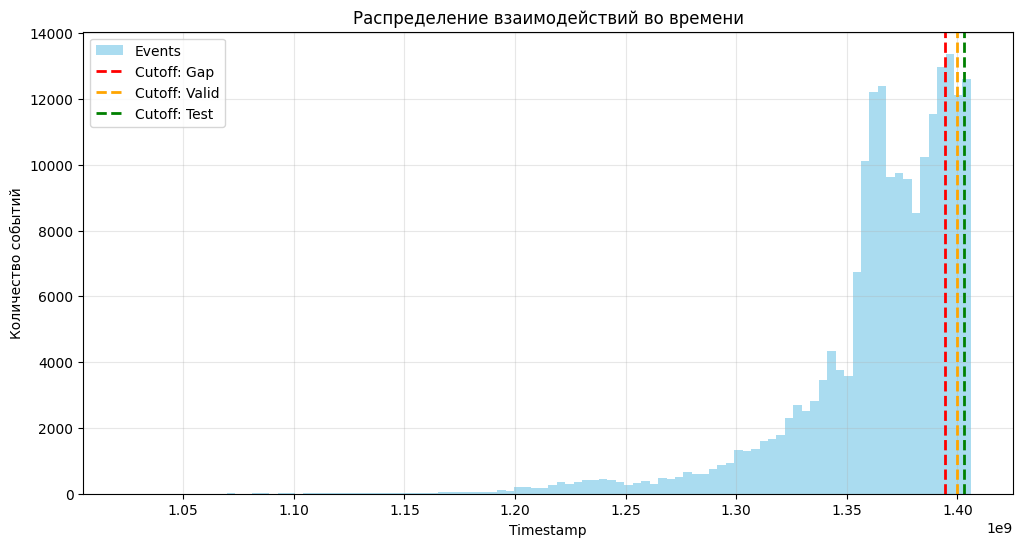

In [27]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
labels = ["Base", "Gap", "Valid", "Test"]

# Считаем события в каждом интервале
counts = []
intervals = [1394150400, 1399939200, 1403049600]
for i in range(len(intervals)-1):
    start, end = intervals[i], intervals[i+1]
    
    q = df.lazy().explode(["timestamps"])
    if end is not None:
        q = q.filter((pl.col("timestamps") >= start) & (pl.col("timestamps") < end))
    else:
        q = q.filter(pl.col("timestamps") >= start)
        
    count = q.select(pl.len()).collect().item()
    counts.append(count)
    
    end_str = datetime.fromtimestamp(end).strftime('%Y-%m-%d') if end else "Inf"
    start_str = datetime.fromtimestamp(start).strftime('%Y-%m-%d') if start > 0 else "Start"
    
    print(f"Part {i} [{labels[i]}]: {count} events ({start_str} -> {end_str})")

# 3. Гистограмма распределения событий во времени
all_timestamps = df.select(pl.col("timestamps").explode()).to_series().to_numpy()

plt.figure(figsize=(12, 6))
plt.hist(all_timestamps, bins=100, color='skyblue', alpha=0.7, label='Events')

# Рисуем линии отсечек
colors = ['red', 'orange', 'green']
for cutoff, color, label in zip(intervals, colors, labels[1:]):
    plt.axvline(x=cutoff, color=color, linestyle='--', linewidth=2, label=f'Cutoff: {label}')

plt.title("Распределение взаимодействий во времени")
plt.xlabel("Timestamp")
plt.ylabel("Количество событий")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()